In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

In [48]:
df = pd.read_csv("housing.csv")
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


# Making a working dataset

In [49]:
df_work = df.copy()

In [50]:
df_work

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


# Preprocessing

In [51]:
df_work.shape

(20640, 10)

In [52]:
df_work.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [53]:
df_work['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [54]:
df_work.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [55]:
df_work['total_bedrooms'].isnull().sum()

np.int64(207)

In [56]:
df_work['total_bedrooms'] = df_work['total_bedrooms'].fillna(df_work['total_bedrooms'].mean())

In [57]:
df_work['total_bedrooms'].isnull().sum()

np.int64(0)

In [58]:
df_work['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [59]:
# This type of encoding is suitable only if there is two class, otherwise go for one hot encoding
# df_work['ocean_proximity'] = df_work['ocean_proximity'].map({
#     "<1H OCEAN": 0,
#     "INLAND": 1,
#     "NEAR OCEAN": 2,
#     "NEAR BAY": 3,
#     "ISLAND":4
# })

In [60]:
df_work = pd.get_dummies(df_work, columns=['ocean_proximity'], drop_first=False, dtype=int)

In [61]:
df_work

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0,0,0,1,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0,0,0,1,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0,0,0,1,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,0,1,0,0,0
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,0,1,0,0,0
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,0,1,0,0,0
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,0,1,0,0,0


# Scaling the value before train test split

In [62]:
scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

In [63]:
X = df_work.drop('median_house_value', axis=1)
y = df_work[['median_house_value']]  
y

,median_house_value
0,452600.0
1,358500.0
2,352100.0
3,341300.0
4,342200.0
...,...
20635,78100.0
20636,77100.0
20637,92300.0
20638,84700.0


In [64]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [65]:
#Data Shape = 100%
#Input feature
# train_x = 80%
#test_x = 20%
#Output variables
#y_train = 80 %
#y_test = 20%
print(df_work.shape)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(20640, 14)
(16512, 13)
(4128, 13)
(16512, 1)
(4128, 1)


# Model Training and Architecture

In [66]:
model = Sequential([
    Input(shape=(X_train.shape[1],)), #input layer
    Dense(1000, activation="relu"), #First Hidden layer
    Dense(500, activation="relu"), #second hidden layer
    Dense(250, activation="relu"), #third hidden layer
    Dense(1, activation="linear") #Output
])

In [67]:
model.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])
es = EarlyStopping(monitor='val_loss', mode='min', patience=50, restore_best_weights=True)

In [68]:
# Fit scaler on TRAIN only, then apply to test (no leakage)
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

y_train = y_scaler.fit_transform(y_train)
y_test = y_scaler.transform(y_test)

In [69]:

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    callbacks=[es],
    epochs=200,
    batch_size=50,
    verbose=1
)

Epoch 1/200
331/331 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0280 - mae: 0.1219 - val_loss: 0.0211 - val_mae: 0.0998
Epoch 2/200
331/331 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0216 - mae: 0.1051 - val_loss: 0.0201 - val_mae: 0.0992
Epoch 3/200
331/331 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0198 - mae: 0.0996 - val_loss: 0.0421 - val_mae: 0.1470
Epoch 4/200
331/331 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0187 - mae: 0.0968 - val_loss: 0.0215 - val_mae: 0.1106
Epoch 5/200
331/331 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0179 - mae: 0.0940 - val_loss: 0.0257 - val_mae: 0.1252
Epoch 6/200
331/331 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0175 - mae: 0.0928 - val_loss: 0.0196 - val_mae: 0.1082
Epoch 7/200
331/331 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0170 - mae: 0.0911 - val_loss: 0.0422 - val_mae: 0.1655
Epoch 8/200
331/331 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0168 - mae: 0.0906 - val_loss: 0.0201 - val_mae: 0.0913
Epoch 9/200
331/331 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/

# Model Result and Prediction

In [70]:
y_pred = model.predict(X_test)

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [71]:
y_pred

array([[0.09783801],
       [0.07934345],
       [0.78473854],
       ...,
       [1.0188859 ],
       [0.14019474],
       [0.3400488 ]], shape=(4128, 1), dtype=float32)

In [72]:
from sklearn.metrics import r2_score, classification_report, mean_absolute_error, mean_squared_error, mean_squared_log_error

In [73]:
# FIX 4: y_test/y_pred are in scaled (0-1) space here. Inverse-transform
# back to real house-price dollars before computing metrics, otherwise
# "mae: 0.088" etc. is meaningless.
y_test_actual = y_scaler.inverse_transform(y_test)
y_pred_actual = y_scaler.inverse_transform(y_pred)

print("mae: ", mean_absolute_error(y_test_actual, y_pred_actual))
print("mse: ", mean_squared_error(y_test_actual, y_pred_actual))
print("msle: ", mean_squared_log_error(y_test_actual, y_pred_actual))
print("Score: ", r2_score(y_test_actual, y_pred_actual))

mae:  35430.842566675
mse:  2836658792.449787
msle:  0.06679764187807447
Score:  0.7835287425870866


In [74]:
history.history

{'loss': [0.0279714222997427,
  0.021551676094532013,
  0.019759749993681908,
  0.018689382821321487,
  0.01788298971951008,
  0.017487341538071632,
  0.01702420972287655,
  0.016819490119814873,
  0.016529614105820656,
  0.01632135547697544,
  0.016133205965161324,
  0.015889042988419533,
  0.01563342660665512,
  0.015445913188159466,
  0.015209140256047249,
  0.015119964256882668,
  0.014769463799893856,
  0.014883924275636673,
  0.014800473116338253,
  0.014566170051693916,
  0.014465884305536747,
  0.014398645609617233,
  0.014324000105261803,
  0.01414559967815876,
  0.014081527478992939,
  0.013841165229678154,
  0.01390052493661642,
  0.013692403212189674,
  0.013760377652943134,
  0.013608100824058056,
  0.013417121022939682,
  0.013426020741462708,
  0.013221396133303642,
  0.013356531038880348,
  0.01324584148824215,
  0.01318412832915783,
  0.013042927719652653,
  0.013003546744585037,
  0.012869689613580704,
  0.012864934280514717,
  0.01284734532237053,
  0.012755168601870

In [75]:
training_loss = history.history['loss']
validation_loss = history.history['val_loss']
epochs = range(1, len(training_loss) + 1)
epochs

range(1, 200)

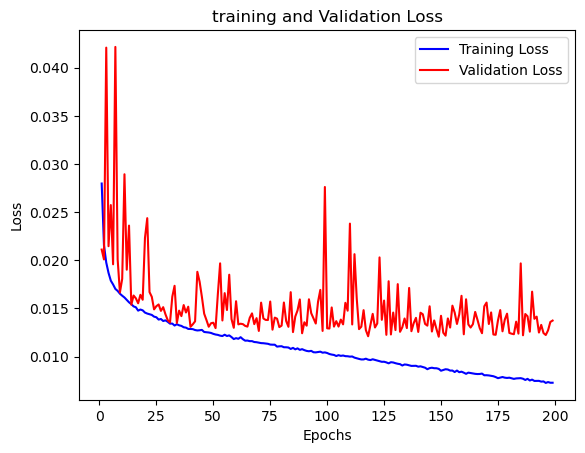

In [76]:
plt.plot(epochs, training_loss, 'b', label='Training Loss')
plt.plot(epochs, validation_loss, 'r', label='Validation Loss')

plt.title("training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [77]:
df_work.iloc[0]

longitude                       -122.2300
latitude                          37.8800
housing_median_age                41.0000
total_rooms                      880.0000
total_bedrooms                   129.0000
population                       322.0000
households                       126.0000
median_income                      8.3252
median_house_value            452600.0000
ocean_proximity_<1H OCEAN          0.0000
ocean_proximity_INLAND             0.0000
ocean_proximity_ISLAND             0.0000
ocean_proximity_NEAR BAY           1.0000
ocean_proximity_NEAR OCEAN         0.0000
Name: 0, dtype: float64

# Predictive System

In [78]:
X.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND',
       'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY',
       'ocean_proximity_NEAR OCEAN'],
      dtype='object')

In [79]:
def pred(longitude, latitude, housing_median_age, total_rooms,
         total_bedrooms, population, households, median_income,
         ocean_proximity):

    # Get training columns
    columns = X.columns.tolist()

    # Create empty dictionary
    data = {}

    # Initialize every feature with 0
    for col in columns:
        data[col] = 0

    # Numerical features
    data["longitude"] = longitude
    data["latitude"] = latitude
    data["housing_median_age"] = housing_median_age
    data["total_rooms"] = total_rooms
    data["total_bedrooms"] = total_bedrooms
    data["population"] = population
    data["households"] = households
    data["median_income"] = median_income

    # One-hot encoding
    if ocean_proximity == "INLAND":
        data["ocean_proximity_INLAND"] = 1
    elif ocean_proximity == "ISLAND":
        data["ocean_proximity_ISLAND"] = 1
    elif ocean_proximity == "NEAR BAY":
        data["ocean_proximity_NEAR BAY"] = 1
    elif ocean_proximity == "NEAR OCEAN":
        data["ocean_proximity_NEAR OCEAN"] = 1
    # <1H OCEAN = all zeros

    # Convert to DataFrame
    df = pd.DataFrame([data])

    # Arrange columns in training order
    df = df[columns]

    # Scale the input
    df_scaled = scaler.transform(df)

    # Predict (in scaled 0-1 space)
    prediction = model.predict(df_scaled, verbose=0)

    # FIX 5: inverse-transform the prediction back to real dollars.
    # This is why your test call printed -39.63952 instead of a house price.
    return y_scaler.inverse_transform(prediction)[0][0]

In [80]:
result = pred(
    longitude=-122.23,
    latitude=37.88,
    housing_median_age=41,
    total_rooms=880,
    total_bedrooms=129,
    population=322,
    households=126,
    median_income=8.3252,
    ocean_proximity="NEAR BAY"
)

In [81]:
print(result)

423327.1


In [82]:
df_work

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0,0,0,1,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0,0,0,1,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0,0,0,1,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,0,1,0,0,0
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,0,1,0,0,0
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,0,1,0,0,0
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,0,1,0,0,0


In [83]:
model.save("model_ann.h5")

In [84]:
import joblib

In [85]:
joblib.dump(X.columns.to_list(), "columns.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [86]:
df_work.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity_<1H OCEAN',
       'ocean_proximity_INLAND', 'ocean_proximity_ISLAND',
       'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN'],
      dtype='object')